In [26]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [27]:
dataset = pd.read_excel("/content/melb_data.xlsx")
dataset.head(3)

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000,S,Biggin,2016-12-03,2.5,3067.0,...,1,1.0,202.0,NaN,NaN,Yarra,NaN,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000,S,Biggin,2016-02-04,2.5,3067.0,...,1,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000,SP,Biggin,2017-03-04,2.5,3067.0,...,2,0.0,134.0,150.0,1900.0,NaN,-37.8093,NaN,Northern Metropolitan,4019.0


In [28]:
dataset.isnull().sum()

,0
Suburb,0
Address,0
Rooms,0
Type,0
Price,0
Method,0
SellerG,0
Date,0
Distance,0
Postcode,138


In [43]:
dataset.describe()

,Rooms,Price,Date,Distance,Postcode,hoal,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount,Longtitude_ss
count,13580.000000,1.358000e+04,13580,13580.000000,13442.000000,13462.000000,13580.000000,13436.000000,13459.000000,7130.000000,8205.000000,13544.000000,13580.000000,13488.000000,1.358000e+04
mean,2.937997,1.075684e+06,2017-01-28 20:25:03.622974976,10.137776,3105.341095,2.916134,1.534242,1.610971,559.298982,151.967650,1964.684217,-37.809286,144.995115,7464.456776,-9.635755e-15
min,1.000000,8.500000e+04,2016-01-28 00:00:00,0.000000,3000.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1196.000000,-38.182550,144.431810,249.000000,-5.428547e+00
25%,2.000000,6.500000e+05,2016-09-10 00:00:00,6.100000,3046.000000,2.000000,1.000000,1.000000,176.000000,93.000000,1940.000000,-37.857000,144.930138,4380.000000,-6.261863e-01
50%,3.000000,9.030000e+05,2017-03-04 00:00:00,9.200000,3084.000000,3.000000,1.000000,2.000000,440.000000,126.000000,1970.000000,-37.802500,144.999750,6567.000000,4.466638e-02
75%,3.000000,1.330000e+06,2017-06-24 00:00:00,13.000000,3148.000000,3.000000,2.000000,2.000000,651.000000,174.000000,1999.000000,-37.756392,145.057448,10331.000000,6.006947e-01
max,10.000000,9.000000e+06,2017-09-23 00:00:00,48.100000,3977.000000,20.000000,8.000000,10.000000,433014.000000,44515.000000,2018.000000,-37.408530,145.526350,21650.000000,5.119488e+00
std,0.955748,6.393107e+05,NaN,5.868725,90.927801,0.964734,0.691712,0.962317,4008.465200,541.014538,37.273762,0.079341,0.103771,4391.370477,1.000037e+00


/tmp/ipython-input-2147052001.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset["Bathroom"])


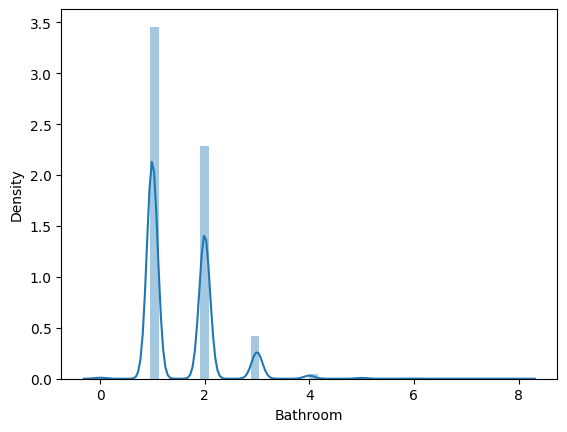

In [44]:
sns.distplot(dataset["Bathroom"])
plt.show()

In [46]:
from sklearn.preprocessing import MinMaxScaler

In [47]:
ms = MinMaxScaler()
ms.fit(dataset[["Bathroom"]])

MinMaxScaler()

In [48]:
dataset["Bathroom_min"] = ms.transform(dataset[["Bathroom"]])

In [49]:
dataset.head(3)

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount,Longtitude_ss,Bathroom_min
0,Abbotsford,85 Turner St,2,h,1480000,S,Biggin,2016-12-03,2.5,3067.0,...,202.0,NaN,NaN,Yarra,NaN,144.998400,Northern Metropolitan,4019.0,0.031656,0.125
1,Abbotsford,25 Bloomburg St,2,h,1035000,S,Biggin,2016-02-04,2.5,3067.0,...,156.0,79.0,1900.0,Yarra,-37.8079,144.993400,Northern Metropolitan,4019.0,-0.016528,0.125
2,Abbotsford,5 Charles St,3,h,1465000,SP,Biggin,2017-03-04,2.5,3067.0,...,134.0,150.0,1900.0,NaN,-37.8093,144.995115,Northern Metropolitan,4019.0,0.000000,0.250


/tmp/ipython-input-2486945278.py:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset["Bathroom_min"])


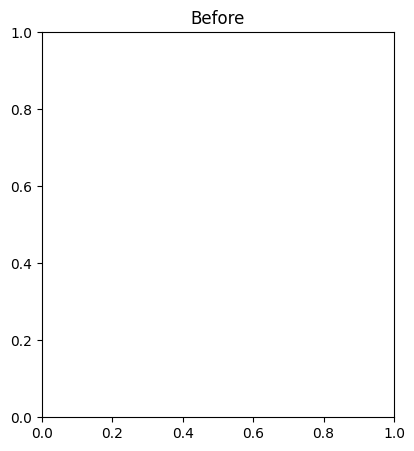

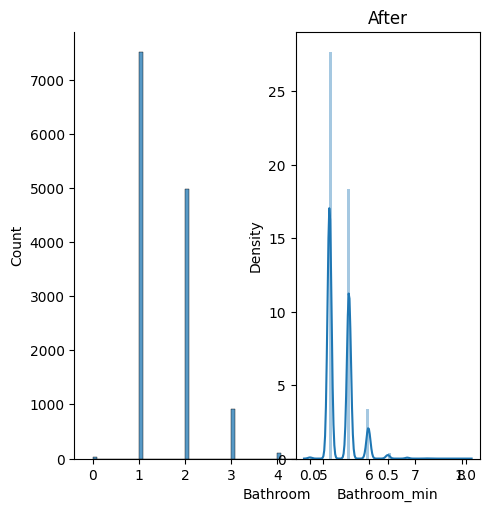

In [50]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title("Before")
sns.displot(dataset["Bathroom"])

plt.subplot(1,2,2)
plt.title("After")
sns.distplot(dataset["Bathroom_min"])

plt.show()